# Lab 7

By Niksh Hiremath (U20240158)


## 1. Code


### Importing libraries


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
)

### Loading datasets


In [23]:
# Loading odi dataset
odi = pd.read_csv("virat_kohli_odi_innings_data.csv")
odi.head()

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date,Odi No
0,12,33,22,1,0,54.54,2,lbw,1,v Sri Lanka,Dambulla,18/08/08,ODI # 2742
1,37,82,67,6,0,55.22,2,caught,2,v Sri Lanka,Dambulla,20/08/08,ODI # 2745
2,25,40,38,4,0,65.78,1,run out,1,v Sri Lanka,Colombo (RPS),24/08/08,ODI # 2750
3,54,87,66,7,0,81.81,1,bowled,1,v Sri Lanka,Colombo (RPS),27/08/08,ODI # 2755
4,31,45,46,3,1,67.39,1,lbw,2,v Sri Lanka,Colombo (RPS),29/08/08,ODI # 2756


In [24]:
# Loading t20 dataset
t20 = pd.read_csv("virat_kohli_t20i_innings_data.csv")
t20.head()

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date,T20I No
0,26,30,21,3,1,123.8,5,not out,2,v Zimbabwe,Harare,12/06/10,T20I # 182
1,DNB,-,-,-,-,-,-,-,2,v Zimbabwe,Harare,13/06/10,T20I # 183
2,28,28,19,5,0,147.36,1,bowled,1,v South Africa,Durban,09/01/11,T20I # 196
3,14,15,12,2,0,116.66,3,caught,1,v West Indies,Port of Spain,04/06/11,T20I # 200
4,4,5,5,0,0,80,4,caught,1,v England,Manchester,31/08/11,T20I # 204


In [25]:
# Loading test dataset
test = pd.read_csv("virat_kohli_test_innings_data.csv")
test.head()

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date,Test No
0,4,13,10,1,0,40,5,caught,1,v West Indies,Kingston,20/06/11,Test # 1997
1,15,72,54,2,0,27.77,5,caught,3,v West Indies,Kingston,20/06/11,Test # 1997
2,0,1,2,0,0,0,5,caught,1,v West Indies,Bridgetown,28/06/11,Test # 1998
3,27,118,107,1,1,25.23,5,caught,3,v West Indies,Bridgetown,28/06/11,Test # 1998
4,30,62,53,2,0,56.6,5,caught,2,v West Indies,Roseau,06/07/11,Test # 1999


### Preprocessing

In [26]:
# Concatenated runs
runs = np.concatenate([odi["Runs"].values, t20["Runs"].values, test["Runs"].values])

# Concatenated strike rates
sr = np.concatenate([odi["SR"].values, t20["SR"].values, test["SR"].values])

# Concatenated grounds
ground = np.concatenate(
    [odi["Ground"].values, t20["Ground"].values, test["Ground"].values]
)

# Concatenated match types
match_type = np.concatenate(
    [
        np.repeat("ODI", len(odi)),
        np.repeat("T20", len(t20)),
        np.repeat("TEST", len(test)),
    ]
)

In [27]:
# Creating a DataFrame
data_cricketer = pd.DataFrame(
    {
        "runs": runs,
        "sr": sr,
        "match_type": match_type,
    }
)
data_cricketer.shape

(556, 3)

In [28]:
data_cricketer.head()

,runs,sr,match_type
0,12,54.54,ODI
1,37,55.22,ODI
2,25,65.78,ODI
3,54,81.81,ODI
4,31,67.39,ODI


In [29]:
# Checking for correct dtypes
data_cricketer.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   runs        556 non-null    str  
 1   sr          556 non-null    str  
 2   match_type  556 non-null    str  
dtypes: str(3)
memory usage: 13.2 KB


In [30]:
# Number of null values in each column
data_cricketer.isnull().sum()

runs          0
sr            0
match_type    0
dtype: int64

In [31]:
# Checking for missing values in runs column
missing_runs = set()
for runs in data_cricketer["runs"]:
    try:
        int(runs)
    except ValueError:
        missing_runs.add(runs)
print("Missing values in runs column:", missing_runs)

Missing values in runs column: {'DNB', 'TDNB'}


In [32]:
# Handling missing values in runs column
data_cricketer["runs"] = data_cricketer["runs"].replace("DNB", 0)
data_cricketer["runs"] = data_cricketer["runs"].replace("TDNB", 0)

# Converting runs column to integer
data_cricketer["runs"] = data_cricketer["runs"].astype(int)

In [33]:
# Checking for missing values in sr column
missing_sr = set()
for sr in data_cricketer["sr"]:
    try:
        float(sr)
    except ValueError:
        missing_sr.add(sr)
print("Missing values in sr column:", missing_sr)

Missing values in sr column: {'-'}


In [34]:
# Handling missing values in sr column
data_cricketer["sr"] = data_cricketer["sr"].replace("-", 0.0)

# Converting sr column to float
data_cricketer["sr"] = data_cricketer["sr"].astype(float)

In [35]:
data_cricketer.info()

<class 'pandas.DataFrame'>
RangeIndex: 556 entries, 0 to 555
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   runs        556 non-null    int64  
 1   sr          556 non-null    float64
 2   match_type  556 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 13.2 KB


In [36]:
data_cricketer.head()

,runs,sr,match_type
0,12,54.54,ODI
1,37,55.22,ODI
2,25,65.78,ODI
3,54,81.81,ODI
4,31,67.39,ODI


### Splitting dataset

In [37]:
X = data_cricketer[["runs", "sr"]]
y = data_cricketer["match_type"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((389, 2), (167, 2), (389,), (167,))

### Model development

In [50]:
svc = SVC(kernel="poly", degree=6, random_state=0)
svc.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",6
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [51]:
y_pred = svc.predict(X_test)

### Model evaluation

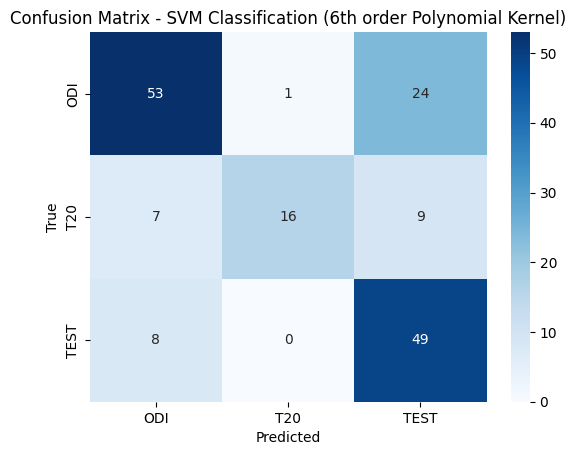

In [62]:
cm = confusion_matrix(y_test, y_pred)

class_labels = ["ODI", "T20", "TEST"]
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)

plt.title("Confusion Matrix - SVM Classification (6th order Polynomial Kernel)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [64]:
acc = accuracy_score(y_test, y_pred)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Balanced Accuracy: {bal_acc:.4f}")

Accuracy: 0.7066
Balanced Accuracy: 0.6797


In [68]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_labels))

Classification Report:
              precision    recall  f1-score   support

         ODI       0.78      0.68      0.73        78
         T20       0.94      0.50      0.65        32
        TEST       0.60      0.86      0.71        57

    accuracy                           0.71       167
   macro avg       0.77      0.68      0.69       167
weighted avg       0.75      0.71      0.70       167



### Scatter plot

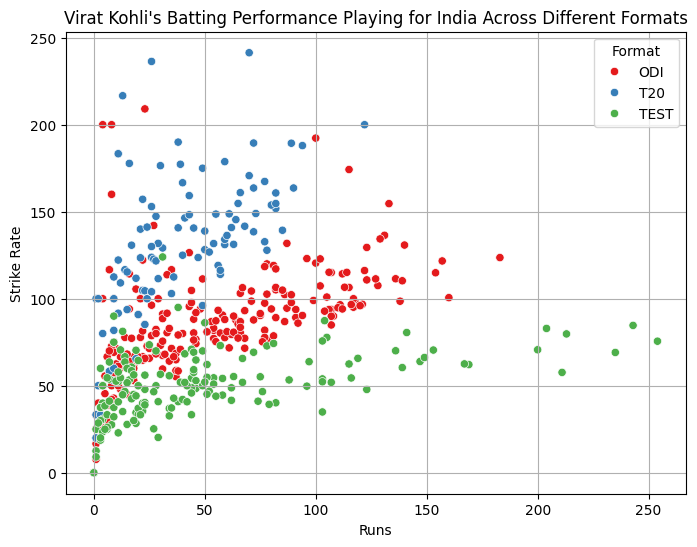

In [81]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=X, x="runs", y="sr", hue=y, palette="Set1")

plt.xlabel("Runs")
plt.ylabel("Strike Rate")
plt.title(
    "Virat Kohli's Batting Performance Playing for India Across Different Formats"
)
plt.legend(title="Format")
plt.grid()
plt.show()

### Hyperparameter tuning on raw data

In [82]:
degrees = range(1, 16)
balanced_accuracies = []

for d in degrees:
    # I added max_iter because it was taking a very long time to converge for higher degree kernels
    svc = SVC(kernel="poly", degree=d, random_state=0, max_iter=100_000_000)
    svc.fit(X_train, y_train)
    y_pred = svc.predict(X_test)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    balanced_accuracies.append(balanced_accuracy)

c:\Users\niksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\niksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\niksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\niksh\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=100000000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
 

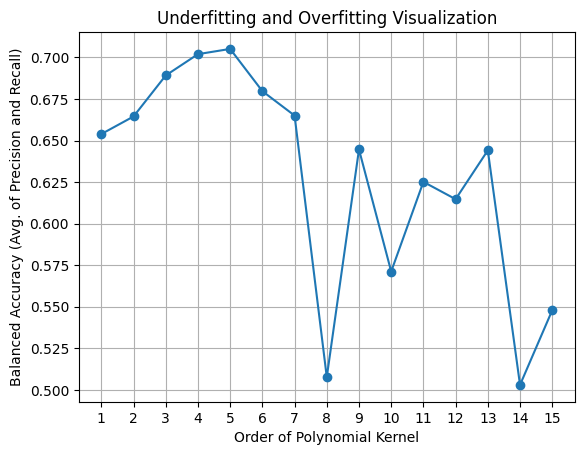

In [84]:
plt.plot(degrees, balanced_accuracies, marker="o")

plt.xlabel("Order of Polynomial Kernel")
plt.ylabel("Balanced Accuracy (Avg. of Precision and Recall)")
plt.xticks(degrees)
plt.title("Underfitting and Overfitting Visualization")

plt.grid()
plt.show()

The above graph is not very accurate because for higher degree kernels (degree > 9), it was taking over 15 minutes each to converge. Hence, I had added `max_iter` above. 

Also from the above graph, it is better to pick kernel of degree 5 over degree 6 kernel.

Also the warning that's given by scikit-learn says to consider preprocessing the data by scaling. And we had also learnt in class to scale data for SVC because it is distance based.

Hence, I have scaled the data and done the hyperparameter tuning again below.

### Feature scaling

In [85]:
std_scaler = StandardScaler()
X_train_scaled = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.transform(X_test)

### Hyperparameter tuning on scaled data

In [88]:
degrees = range(1, 16)
balanced_accuracies_scaled = []

for d in degrees:
    svc = SVC(kernel="poly", degree=d, random_state=0)
    svc.fit(X_train_scaled, y_train)
    y_pred = svc.predict(X_test_scaled)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    balanced_accuracies_scaled.append(balanced_accuracy)

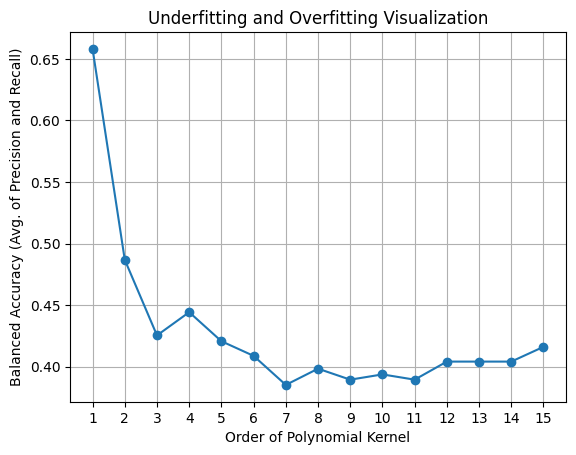

In [89]:
plt.plot(degrees, balanced_accuracies_scaled, marker="o")

plt.xlabel("Order of Polynomial Kernel")
plt.ylabel("Balanced Accuracy (Avg. of Precision and Recall)")
plt.xticks(degrees)
plt.title("Underfitting and Overfitting Visualization")

plt.grid()
plt.show()

From the plot of hyperparameter tuning for differnt kernel degrees on scaled data, we can see that a simple linear kernel is more than sufficient for the given data.

## 2. Report


### Q1: What are Support Vectors in SVM? How do they help in making SVM less prone to outliers? 

**Ans:** 

- Support vectors are the boundary datapoints of each class that lie closest to the decision hyperplane.

- They are the only points that define the position and orientation of the hyperplane. All other points are irrelevant to the decision rule.

- Since outliers far from the boundary have zero influence on the hyperplane, SVM is less prone to outliers.

---


### Q2: What is the difference between a hard margin and a soft margin in SVM? 

**Ans:** 

- Hard margin: No misclassifications allowed. All points must be on the correct side of the margin. 

- Soft margin: Introduces a slack variable that permits some points to violate the margin or be misclassified.

Soft margin is preferred for real world data as it handles noise, overlap, and non linear separability, and helps prevent overfitting.

---


### Q3: How does SVM deal with non-linear classification boundaries? 

**Ans:** 

- SVM uses the kernel trick to map data into a higher dimensional feature space where a linear hyperplane can separate the classes.

- Common kernels: Linear, RBF, Polynomial and Sigmoid.

---


### Q4: What is the role of gamma in SVM? How does the value of gamma impact underfitting/overfitting?

**Ans:** Gamma defines the radius of influence of each training point.

- Low gamma: Distant points are considered. Produces a smooth, generalised boundary at the risk of underfitting.

- High gamma: Only nearby points matter. Boundary wraps tightly around individual points at the risk of overfitting.

Optimal gamma balances the two extremes for best generalisation.

---


### Q5: How are SVMs used for multi-class classification problems?

**Ans:** 

- One vs One: A binary classifier is trained for every pair of classes and final prediction is by majority vote.

- One vs Rest: One classifier per class, treating that class as positive and all others as negative.

---
